In [ ]:
import numpy as np

class Node:
    def __init__(self, feature_index = None, threshold = None, left = None, right = None, value = None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def gini_impurity(y):
    """Calculate the Gini impurity of a label array."""
    if(len(y) == 0):
        return 0
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / y.size
    return 1-np.sum(probabilities ** 2)

def information_gain(y, y_left, y_right):
    """Calculate the information gain of a split."""
    if(len(y) == 0):
        return 0
    weight_left = len(y_left) / len(y)
    weight_right = len(y_right) / len(y)

    parent_impurity = gini_impurity(y)
    child_impurity = weight_left * gini_impurity(y_left) + weight_right * gini_impurity(y_right)
    return parent_impurity - child_impurity

def split_dataset(X,y, feature_index, threshold):
    """Split the dataset based on a feature and threshold."""
    X_left= X[X[:,feature_index]<=threshold]
    X_right = X[X[:,feature_index]>threshold]
    y_left = y[X[:,feature_index]<=threshold]
    y_right = y[X[:,feature_index]>threshold]

    return X_left,y_left,X_right,y_right

def get_best_split(X,y):
    best_ig = 0
    best_feature = -1
    best_threshold = -1

    for j in range(X.shape[1]) :
        feature_column = X[:, j]
        unique_feature_column = np.unique(feature_column)

        for t in unique_feature_column:
            X_left,y_left,X_right,y_right = split_dataset(X,y,j,t)

            if len(y_right) ==0 or len(y_left) == 0:
                continue
            current_info_gain = information_gain(y, y_left, y_right)

            if current_info_gain > best_ig:
                best_ig = current_info_gain
                best_feature = j
                best_threshold = t

    return best_feature,best_threshold

def get_leaf_value(y):
    return np.argmax(np.bincount(y))

In [ ]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100):
        self.root = None
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth

    def _build_tree(self, X, y, current_depth=0):
        if current_depth >= self.max_depth or X.shape[0] < self.min_samples_split or np.unique(y).size == 1:
            leaf_value = get_leaf_value(y)
            return Node(value = leaf_value)

        feature_index,threshold = get_best_split(X,y)

        if(feature_index == -1):
            leaf_value = get_leaf_value(y)
            return Node(value = leaf_value)

        X_left,y_left,X_right,y_right = split_dataset(X,y,feature_index,threshold)

        left_child = self._build_tree(X_left,y_left,current_depth+1)
        right_child = self._build_tree(X_right,y_right,current_depth+1)

        return Node(feature_index,threshold,left_child,right_child)

    def fit(self,X,y):
        self.root = self._build_tree(X, y)

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value

        feature_index = node.feature_index
        threshold = node.threshold

        if(x[feature_index]<=threshold):
            return self._traverse_tree(x,node.left)
        return self._traverse_tree(x,node.right)

    def predict(self, X):
        predictions = []
        for x in X:
            predictions.append(self._traverse_tree(x, self.root))
        return np.array(predictions)
    def print_tree(self, node=None, indent=""):
        # Default to root on the first call
        if node is None:
            node = self.root

        # Base case: We reached a leaf
        if node.value is not None:
            print(f"{indent}Leaf: Predict Class {node.value}")
            return

        # Recursive step: Print decision and traverse children
        print(f"{indent}If Feature {node.feature_index} <= {node.threshold:.2f}:")
        self.print_tree(node.left, indent + "  |  ")
        
        print(f"{indent}Else (Feature {node.feature_index} > {node.threshold:.2f}):")
        self.print_tree(node.right, indent + "  |  ")

In [9]:
# Synthetic 2D dataset
X_train = np.array([
    [1.5, 2.0], 
    [1.0, 3.0], 
    [5.0, 4.0], 
    [6.0, 5.0], 
    [1.0, 1.0], 
    [6.0, 1.0]
])
# The rule: if feature 0 <= 3.0, class is 0. If feature 0 > 3.0, class is 1.
y_train = np.array([0, 0, 1, 1, 0, 1])

# Run it:
tree = DecisionTree(max_depth=3)
tree.fit(X_train, y_train)
predictions = tree.predict(X_train)
tree.print_tree()

print("Predictions:", predictions)
print("Actuals:    ", y_train)

If Feature 0 <= 1.50:
  |  Leaf: Predict Class 0
Else (Feature 0 > 1.50):
  |  Leaf: Predict Class 1
Predictions: [0 0 1 1 0 1]
Actuals:     [0 0 1 1 0 1]


In [7]:
from sklearn.tree import DecisionTreeClassifier

# Your DecisionTree(max_depth=3, min_samples_split=2) maps to:
clf = DecisionTreeClassifier(
    criterion='gini',       # We implemented Gini impurity
    max_depth=3,            # Depth stopping condition
    min_samples_split=2     # Sample size stopping condition
)

clf.fit(X_train, y_train)
predictions = clf.predict(X_train)
print(predictions)

[0 0 1 1 0 1]


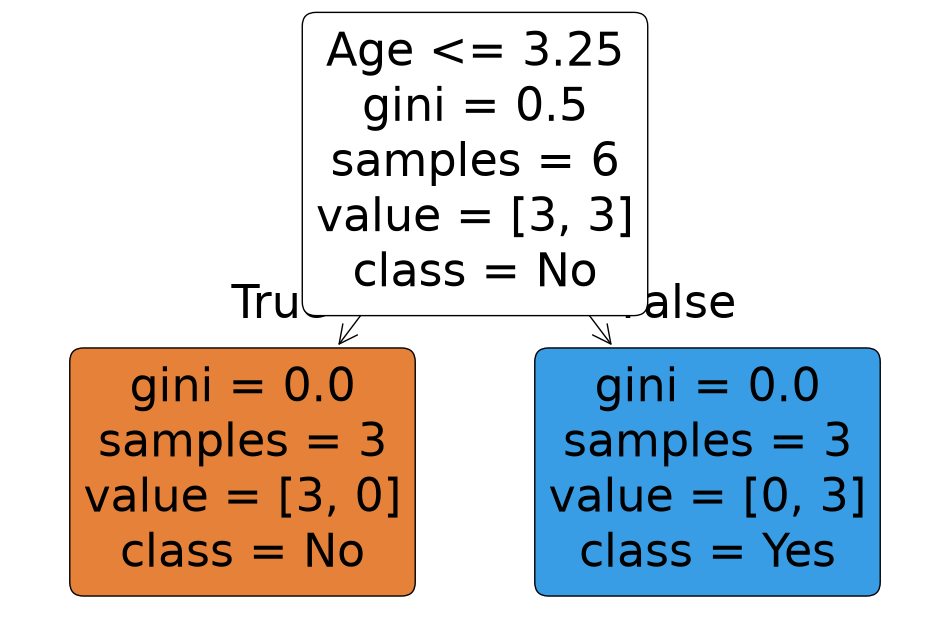

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Assuming 'clf' is your trained sklearn DecisionTreeClassifier
plt.figure(figsize=(12, 8))
plot_tree(
    clf, 
    filled=True,                     # Color-codes nodes by class
    feature_names=['Age', 'Income'], # Replaces "Feature 0" with actual names
    class_names=['No', 'Yes'],       # Replaces "Class 0" with actual labels
    rounded=True
)
plt.show()